# <font style="color:blue">Table of Content</font>

- [Step 1: Understand Your Problem](#step1)
- [Step 2: Get the Data](#step2)
- [Step 3. Data Preparation](#step3)
- [Step 4: Train a Simple Model](#step4)
- [Step 5: Sample Prediction](#step5)
- [Step 6. Display Mistakes](#step6)

# <font style="color:blue">Project 1 - Part 2: Train an Image Classifier From Scratch</font>
As discussed in the previous notebook, the steps for training Neural Networks are:

- Step 1 - Understand your problem
- Step 2A - Get the data
- Step 2B - Explore and understand your data
- Step 2C - Create a sample data from the dataset
- Step 3 - Data preparation
- Step 4 - Train a simple model on sample data and check the pipeline before proceeding to train the full network
- Step 5 - Train on full data
- Step 6 - Improve your model

You have already been through Steps `1-4` in the previous notebook. Use them here as well.

Here, you will implement Steps `5` & `6` from scratch. Design a model that achieves `>=85%` validation accuracy on the given dataset.

There are 70 points for this notebook. The sections which carry marks are in Red.

There are **70 points** for this notebook. <font style="color:red">The sections which carry marks are in Red.</font>

For GPU compute you can use Kaggle Kernels, Google Colab or any other service of your choice.

After completing the assignment, upload and submit it on the portal for feedback.

<font style="color:red">Use the full data to train the network. You need to achieve 85% accuracy for validation data to successfully complete this assignment.</font>


<font style="color:red">Just remember to build your own model, not use any pre-trained models/weights.</font>


Upon completing the assignment, <font style="color:red">upload the notebook and the models folder on the portal for  feedback.</font>

# <font style="color:blue">Step 1: Understand Your problem </font><a name="step1"></a>
Already covered in the previous notebook.

# <font style="color:blue">Step 2: Get the Data </font><a name="step2"></a>

Already covered in the previous notebook.

In [1]:
# !wget "https://www.dropbox.com/sh/n5nya3g3airlub6/AACi7vaUjdTA0t2j_iKWgp4Ra?dl=1" -O data.zip

### <font style="color:green">Extract the Data</font>

In [2]:
# !unzip -q data.zip

# <font style="color:blue">Step 3. Data Preparation</font><a name="step3"></a>
Already covered in the previous notebook.

## <font style="color:blue">3.1. Import Libraries </font>

In [3]:
%matplotlib inline

In [4]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [5]:
import os
import time

from typing import Iterable
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms

from torch.optim import lr_scheduler

### <font style="color:green">3.2.1. Compulsary Preprocessing Transforms</font>

In [6]:
def image_preprocess_transforms():
    
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor()
        ])
    
    return preprocess

### <font style="color:green">3.2.2. Common Image Transforms</font>

In [7]:
def image_common_transforms(mean=(0.4611, 0.4359, 0.3905), std=(0.2193, 0.2150, 0.2109)):
    preprocess = image_preprocess_transforms()
    
    common_transforms = transforms.Compose([
        preprocess,
        transforms.Normalize(mean, std)
    ])
    
    return common_transforms
    

### <font style="color:red">3.2.2. Data Augmentation Transforms</font>

In [8]:
from torchvision.transforms import v2

def data_augmentation_transforms(mean=(0.4611, 0.4359, 0.3905), 
                                 std=(0.2193, 0.2150, 0.2109)):
    
    augmentation_options=[
                          v2.ElasticTransform(alpha=100.0, sigma = 5.0),
                          v2.RandomResizedCrop(size=(256, 256), scale=(0.0,1.0)),
                          v2.RandomHorizontalFlip(p=0.5),
                          v2.RandomVerticalFlip(p=0.5),
                          v2.RandomRotation(degrees=65),
                          v2.AugMix(severity= 5),
                         ]
    preprocess = image_preprocess_transforms()
    
    _transforms = v2.Compose([
        transforms.RandomChoice(transforms=augmentation_options), 
        preprocess,
        transforms.Normalize(mean, std)
    ])
    
    return _transforms
    

### <font style="color:green">3.2.3. Mean and STD</font>

In [9]:
def get_mean_std(data_root, num_workers=4):
    
    transform = image_preprocess_transforms()
    
    loader = data_loader(data_root, transform)
    
    batch_mean = torch.zeros(3)
    batch_mean_sqrd = torch.zeros(3)
    
    for batch_data, _ in loader:
        batch_mean += batch_data.mean(dim=(0, 2, 3)) # E[batch_i] 
        batch_mean_sqrd += (batch_data ** 2).mean(dim=(0, 2, 3)) #  E[batch_i**2]
    
    # E[dataset] = E[E[batch_1], E[batch_2], ...]
    mean = batch_mean / len(loader)
    
    # var[X] = E[X**2] - E[X]**2
    
    # E[X**2] = E[E[batch_1**2], E[batch_2**2], ...]
    # E[X]**2 = E[E[batch_1], E[batch_2], ...] ** 2
    
    var = (batch_mean_sqrd / len(loader)) - (mean ** 2)
        
    std = var ** 0.5
    print('mean: {}, std: {}'.format(mean, std))
    
    return mean, std

## <font style="color:blue">3.3. Data Loaders </font>

### <font style="color:green">3.3.1. Data Loader for Full Data</font>
Data loader for generating batches of data to be used by the training routine

In [10]:
def data_loader(data_root, transform, batch_size=16, shuffle=False, num_workers=2):
    dataset = datasets.ImageFolder(root=data_root, transform=transform)
    
    loader = torch.utils.data.DataLoader(dataset, 
                                         batch_size=batch_size,
                                         num_workers=num_workers,
                                         shuffle=shuffle)
    
    return loader

## <font style="color:green">3.4. Prepare Data</font>
The main function which uses all the above functions to generate the train and test dataloaders.


In [11]:
def get_data(batch_size, data_root, num_workers=4, data_augmentation=False):
    """
    setup pytorch data loaders for training and validation data 
    """
    train_data_path = os.path.join(data_root, 'training')
    valid_data_path = os.path.join(data_root, 'validation')

    mean, std = get_mean_std(data_root=train_data_path, num_workers=num_workers)

    common_transforms = image_common_transforms(mean, std)
    
    if data_augmentation:
        data_transformations = data_augmentation_transforms(mean, std)
    else:
        data_transformations = common_transforms

    train_loader = data_loader(train_data_path,
                               transform=data_transformations,
                               batch_size=batch_size,
                               shuffle=True,
                               num_workers=num_workers)
    
    valid_loader = data_loader(valid_data_path,
                               transform=common_transforms,
                               batch_size=batch_size,
                               shuffle=True,
                               num_workers=num_workers)
    return train_loader,valid_loader


# <font style="color:blue">Step 4: Train Your Model</font><a name="step4"></a>

Now, create the training pipeline, and train your model on the full data.

## <font style="color:red">4.1. Configurations [20 Points]</font>

To achieve good results, change the parameters given in these configurations. Score 20 points for all right choices.

### <font style="color:green">4.1.1. System Configuration</font>

Fix the seed (e.g., `21`) to get a reproducible result. 

In [12]:
@dataclass
class SystemConfiguration:
    '''
    Describes the common system setting needed for reproducible training
    '''
    seed: int = 21  # seed number to set the state of all random number generators
    cudnn_benchmark_enabled: bool = True  # enable CuDNN benchmark for the sake of performance
    cudnn_deterministic: bool = True  # make cudnn deterministic (reproducible training)

### <font style="color:green">4.1.2. Training Configuration</font>

In [13]:
@dataclass
class TrainingConfiguration:
    '''
    Describes configuration of the training process
    '''
    batch_size: int = 4      # 10 
    epochs_count: int = 20    # 50  
    init_learning_rate: float = 0.001  ## 0.1  # initial learning rate for lr scheduler
    log_interval: int = 5  
    test_interval: int = 1  
    data_root: str = "./cat-dog-panda" 
    num_workers: int = 2  
    device: str = 'cuda'  
    model_name:str = 'unknown'
    dropout_rate:float = 0.0
    run_name: str =""

### <font style="color:green">4.1.3. System Setup</font>

In [14]:
def setup_system(system_config: SystemConfiguration) -> None:
    torch.manual_seed(system_config.seed)
    if torch.cuda.is_available():
        torch.backends.cudnn_benchmark_enabled = system_config.cudnn_benchmark_enabled
        torch.backends.cudnn.deterministic = system_config.cudnn_deterministic

### <font style="color:green">4.1.4. Metrics </font>

In [15]:
class Metrics():
    def __init__(self):
        self.best_loss_ep = -1
        self.best_loss = torch.tensor(np.inf)
        self.best_loss_acc = 0.0
        self.best_acc = 0.0

        # epoch train/test loss
        self.train_loss = np.array([])
        self.val_loss = np.array([])
        self.test_loss = np.array([])

        # epch train/test accuracy
        self.train_acc = np.array([])
        self.val_acc = np.array([]) 
        self.test_acc = np.array([]) 

        

## <font style="color:blue">4.2. Training Function</font>

You are already familiar with the training function. No changes needed here.

In [16]:
def train(
    train_config: TrainingConfiguration, model: nn.Module, optimizer: torch.optim.Optimizer,
    train_loader: torch.utils.data.DataLoader, epoch_idx: int
) -> None:
    
    # change model in training mood
    model.train()
    
    # to get batch loss
    batch_loss = np.array([])
    
    # to get batch accuracy
    batch_acc = np.array([])
        
    for batch_idx, (data, target) in enumerate(train_loader):
        
        # clone target
        indx_target = target.clone()
        # send data to device (its is medatory if GPU has to be used)
        data = data.to(train_config.device)
        # send target to device
        target = target.to(train_config.device)

        # reset parameters gradient to zero
        optimizer.zero_grad()
        
        # forward pass to the model
        output = model(data)
        
        # cross entropy loss
        loss = F.cross_entropy(output, target)
        
        # find gradients w.r.t training parameters
        loss.backward()
        # Update parameters using gardients
        optimizer.step()
        
        batch_loss = np.append(batch_loss, [loss.item()])
        
        # Score to probability using softmax
        prob = F.softmax(output, dim=1)
            
        # get the index of the max probability
        pred = prob.data.max(dim=1)[1]  
                        
        # correct prediction
        correct = pred.cpu().eq(indx_target).sum()
            
        # accuracy
        acc = float(correct) / float(len(data))
        
        batch_acc = np.append(batch_acc, [acc])
            
    epoch_loss = batch_loss.mean()
    epoch_acc = batch_acc.mean()
    # print('Epoch: {} \nTrain Loss: {:.6f} Acc: {:.4f}'.format(epoch_idx, epoch_loss, epoch_acc))
    return epoch_loss, epoch_acc

## <font style="color:blue">4.3. Validation Function</font>

In [17]:
def validate(
    train_config: TrainingConfiguration,
    model: nn.Module,
    test_loader: torch.utils.data.DataLoader,
) -> float:
    # 
    model.eval()
    test_loss = 0
    count_corect_predictions = 0
    for data, target in test_loader:
        indx_target = target.clone()
        data = data.to(train_config.device)
        
        target = target.to(train_config.device)
        
        with torch.no_grad():
            output = model(data)
        
        # add loss for each mini batch
        test_loss += F.cross_entropy(output, target).item()
        
        # Score to probability using softmax
        prob = F.softmax(output, dim=1)
        
        # get the index of the max probability
        pred = prob.data.max(dim=1)[1] 
        
        # add correct prediction count
        count_corect_predictions += pred.cpu().eq(indx_target).sum()

    # average over number of mini-batches
    test_loss = test_loss / len(test_loader)  
    
    # average over number of dataset
    accuracy = count_corect_predictions / len(test_loader.dataset)
    
    # print(
    #     '\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    #         test_loss, count_corect_predictions, len(test_loader.dataset), accuracy
    #     )
    # )
    
    return test_loss, accuracy

## <font style="color:blue">4.4. Save the Model</font>

In [18]:
def save_model(model, device, model_dir='models', model_file_name='cat_dog_panda_classifier.pt'):
    

    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    model_path = os.path.join(model_dir, model_file_name)

    # make sure you transfer the model to cpu.
    if device == 'cuda':
        model.to('cpu')

    # save the state_dict
    torch.save(model.state_dict(), model_path)
    
    if device == 'cuda':
        model.to('cuda')
    
    return

## <font style="color:blue">4.5. Load the Model</font>

In [19]:
def load_model(model, model_dir='models', model_file_name='cat_dog_panda_classifier.pt'):
    model_path = os.path.join(model_dir, model_file_name)

    # loading the model and getting model parameters by using load_state_dict
    model.load_state_dict(torch.load(model_path))
    
    return model

## <font style="color:blue">4.6. Main Function for Training</font>

Note: Before calling the train function, we calculate the validation loss, which we know should be close to $\log(\text{num_classes})$. Also, the accuracy should be close to $\frac{1}{\text{num_classes}}$.

In [20]:
def main(model, 
         optimizer, 
        scheduler=None, 
        system_configuration=None, 
        training_configuration=None, 
        metrics = None,
        data_augmentation=True,
        # subset_size =1.0,
        # # epoch loss
        # epoch_train_loss = None,
        # epoch_test_loss = None,
        # # epch accuracy
        # epoch_train_acc = None,
        # epoch_test_acc = None,
        # best_loss = None,          
        ):
    
    # system configuration
    setup_system(system_configuration)

    # if GPU is available use training config, 
    # else lowers batch_size, num_workers and epochs count
    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
 
    # batch size
    batch_size_to_set = training_configuration.batch_size
    # num_workers
    num_workers_to_set = training_configuration.num_workers
    # epochs
    epoch_num_to_set = training_configuration.epochs_count

    
    # data loader
    train_loader, test_loader = get_data(
        batch_size=batch_size_to_set,
        data_root=training_configuration.data_root,
        num_workers=num_workers_to_set,
        data_augmentation=data_augmentation,
    )

    # send model to device (GPU/CPU)
    model.to(training_configuration.device)

    # Calculate Initial Test Loss
    init_val_loss, init_val_accuracy = validate(training_configuration, model, test_loader)
    print(f" Model: {train_config.model_name}   Batch Size: {train_config.batch_size}   Init LR: {train_config.init_learning_rate}  Epochs in this run: {training_configuration.epochs_count}")
    print(" Initial Test Loss : {:.6f} \t Initial Test Accuracy : {:.3f} %\n".format(init_val_loss, 
                                                                                   init_val_accuracy*100))
    
    # trainig time measurement
    print(" Epoch     Train Loss      Train Acc           Test Loss       Test Acc         Elpsd(s)   (s/epoch)   (s/batch)   ETA (s)      LR \n")
    t_begin = time.time()
    for epoch in range(train_config.epochs_count):

        # Train
        train_loss, train_acc = train(train_config, model, optimizer, train_loader, epoch)

        metrics.train_loss = np.append(metrics.train_loss, [train_loss])

        metrics.train_acc = np.append(metrics.train_acc, [train_acc])

        elapsed_time = time.time() - t_begin
        speed_epoch = elapsed_time / (epoch + 1)
        speed_batch = speed_epoch / len(train_loader)
        eta = speed_epoch * train_config.epochs_count - elapsed_time

        # Validate
        if epoch % train_config.test_interval == 0:
            current_loss, current_accuracy = validate(train_config, model, test_loader)

            metrics.val_loss = np.append(metrics.val_loss, [current_loss])
            metrics.val_acc  = np.append(metrics.val_acc, [current_accuracy])

            print(" {:3d}   {:14.6f}         {:.4f}      {:14.6f}         {:.4f}     {:10.2f}     {:7.2f}    {:7.2f}     {:7.1f}     {:.1e}".format(
                    epoch, train_loss, train_acc, current_loss, current_accuracy, elapsed_time, speed_epoch, speed_batch, eta, optimizer.param_groups[0]['lr']), end='')
 
            if current_accuracy > metrics.best_acc:
                metrics.best_acc = current_accuracy
                metrics.best_acc_loss = current_loss
                metrics.best_acc_ep = epoch
                print(f"   Acc Improved: {metrics.best_acc*100:.2f}% .", end="")
                save_model(model, device=train_config.device, 
                           model_file_name=train_config.run_name+"_bestacc.pt")
                
            if current_loss < metrics.best_loss:
                metrics.best_loss = current_loss
                metrics.best_loss_acc = current_accuracy
                metrics.best_loss_ep = epoch
                print(f"   Loss Improved: {metrics.best_loss:.6f} .")
                save_model(model, device=train_config.device, 
                           model_file_name=train_config.run_name+"_bestloss.pt")
            else:
                print()

        # Scheduler step
        # print(type(epoch_test_loss), epoch_test_loss.shape)
        scheduler.step(current_loss)
        # wandb_session.log({'trn_loss': train_loss, 'trn_acc': train_acc, 
        #                    'val_loss':current_loss, 'val_acc' : current_accuracy, 
        #                    'best_loss':metrics.best_loss, 'best_acc':metrics.best_acc,
        #                    'best_loss_ep':metrics.best_loss_ep, 'best_acc_ep': metrics.best_acc_ep})
    print()
    print("-"*100)    
    print("  Total time: {:.2f}  \n" \
          "  Best Loss Epoch: {:4d}     Best Loss:   {:.6f}      Best Loss Accuracy: {:.3f} % \n" \
          "  Best Acc  Epoch: {:4d}     Best Accuracy: {:.3f} %    Best Accuracy Loss: {:.6f}".format(
             time.time() - t_begin, 
             metrics.best_loss_ep, metrics.best_loss, metrics.best_loss_acc*100,
             metrics.best_acc_ep , metrics.best_acc * 100, metrics.best_acc_loss))
    print("-"*100)    

    return model, metrics ##  epoch_train_loss, epoch_train_acc, epoch_test_loss, epoch_test_acc, best_loss


In [21]:
# def main(model, optimizer, scheduler=None, system_configuration=SystemConfiguration(), 
#          training_configuration=TrainingConfiguration(), data_augmentation=True):
    
#     # system configuration
#     setup_system(system_configuration)

#     # batch size
#     batch_size_to_set = training_configuration.batch_size
#     # num_workers
#     num_workers_to_set = training_configuration.num_workers
#     # epochs
#     epoch_num_to_set = training_configuration.epochs_count

#     # if GPU is available use training config, 
#     # else lowers batch_size, num_workers and epochs count
#     if torch.cuda.is_available():
#         device = "cuda"
#     else:
#         device = "cpu"
#         batch_size_to_set = 16
#         num_workers_to_set = 4

#     # data loader
#     train_loader, test_loader = get_data(
#         batch_size=batch_size_to_set,
#         data_root=training_configuration.data_root,
#         num_workers=num_workers_to_set,
#         data_augmentation=data_augmentation
#     )
    
#     # Update training configuration
#     training_configuration = TrainingConfiguration(
#         device=device,
#         batch_size=batch_size_to_set,
#         num_workers=num_workers_to_set
#     )
        
#     # send model to device (GPU/CPU)
#     model.to(training_configuration.device)

#     best_loss = torch.tensor(np.inf)
    
#     # epoch train/test loss
#     epoch_train_loss = np.array([])
#     epoch_test_loss = np.array([])
    
#     # epch train/test accuracy
#     epoch_train_acc = np.array([])
#     epoch_test_acc = np.array([])
    
#     # Calculate Initial Test Loss
#     init_val_loss, init_val_accuracy = validate(training_configuration, model, test_loader)
#     print("Initial Test Loss : {:.6f}, \nInitial Test Accuracy : {:.3f}%\n".format(init_val_loss, 
#                                                                                    init_val_accuracy*100))
    
#     # trainig time measurement
#     t_begin = time.time()
#     for epoch in range(training_configuration.epochs_count):
        
#         # Train
#         train_loss, train_acc = train(training_configuration, model, optimizer, train_loader, epoch)
        
#         epoch_train_loss = np.append(epoch_train_loss, [train_loss])
        
#         epoch_train_acc = np.append(epoch_train_acc, [train_acc])

#         elapsed_time = time.time() - t_begin
#         speed_epoch = elapsed_time / (epoch + 1)
#         speed_batch = speed_epoch / len(train_loader)
#         eta = speed_epoch * training_configuration.epochs_count - elapsed_time
        
#         print(
#             "Elapsed {:.2f}s, {:.2f} s/epoch, {:.2f} s/batch, ets {:.2f}s".format(
#                 elapsed_time, speed_epoch, speed_batch, eta
#             )
#         )

#         # Validate
#         if epoch % training_configuration.test_interval == 0:
#             current_loss, current_accuracy = validate(training_configuration, model, test_loader)
            
#             epoch_test_loss = np.append(epoch_test_loss, [current_loss])
        
#             epoch_test_acc = np.append(epoch_test_acc, [current_accuracy])
            
#             if current_loss < best_loss:
#                 best_loss = current_loss
#                 print('Model Improved. Saving the Model...\n')
#                 save_model(model, device=training_configuration.device)
        
                
#     print("Total time: {:.2f}, Best Loss: {:.3f}".format(time.time() - t_begin, best_loss))
    
#     return model, epoch_train_loss, epoch_train_acc, epoch_test_loss, epoch_test_acc

## <font style="color:blue">4.7. Plot Loss and Accuracy</font>

In [22]:
def plot_loss_accuracy(train_loss, val_loss, train_acc, val_acc, colors, 
                       loss_legend_loc='upper center', acc_legend_loc='upper left', 
                       fig_size=(15.0, 5.0), sub_plot1=(1, 2, 1), sub_plot2=(1, 2, 2),
                        trn_config = None):
    
    plt.rcParams["figure.figsize"] = fig_size
    fig = plt.figure()
    
    plt.subplot(sub_plot1[0], sub_plot1[1], sub_plot1[2])
    
    for i in range(len(train_loss)):
        x_train = range(len(train_loss[i]))
        x_val = range(len(val_loss[i]))
        
        min_train_loss = train_loss[i].min()
        
        min_val_loss = val_loss[i].min()
        
        plt.plot(x_train, train_loss[i], linestyle='-', color='tab:{}'.format(colors[i]), 
                 label="TRAIN LOSS ({0:.4})".format(min_train_loss))
        plt.plot(x_val, val_loss[i], linestyle='--' , color='tab:{}'.format(colors[i]), 
                 label="VALID LOSS ({0:.4})".format(min_val_loss))
        
    plt.xlabel('epoch no.')
    plt.ylabel('loss')
    plt.legend(loc=loss_legend_loc)
    plt.title('Training and Validation Loss')
        
    plt.subplot(sub_plot2[0], sub_plot2[1], sub_plot2[2])
    
    for i in range(len(train_acc)):
        x_train = range(len(train_acc[i]))
        x_val = range(len(val_acc[i]))
        
        max_train_acc = train_acc[i].max() 
        
        max_val_acc = val_acc[i].max() 
        
        plt.plot(x_train, train_acc[i], linestyle='-', color='tab:{}'.format(colors[i]), 
                 label="TRAIN ACC ({0:.4})".format(max_train_acc))
        plt.plot(x_val, val_acc[i], linestyle='--' , color='tab:{}'.format(colors[i]), 
                 label="VALID ACC ({0:.4})".format(max_val_acc))
        
    plt.xlabel('epoch no.')
    plt.ylabel('accuracy')
    plt.legend(loc=acc_legend_loc)
    plt.title('Training and Validation Accuracy')
    
    fig.savefig(f"{trn_config.model_name}_bs{trn_config.batch_size}_lr{trn_config.init_learning_rate}_sample_loss_acc_plot.png")
    plt.show()
    
    return   

## <font style="color:red">4.8. Define Model [20 Points]</font>

Next, define the CNN model. Keep iterating. Do this by training various models. Just ,change the :
    
- number of layers
- parameters inside the layers
- different types of layers

In [23]:
import torch.nn.init as init
class MyModel(nn.Module):
    def __init__(self, p = 0.2):
        super().__init__()
        self.name = "Model_v8"
        self.p = p
        k3 = 3
        k5 = 5
        k7 = 7
        l1_out = 256
        l2_out = 512
        l3_out = 2048
        l4_out = 4096
        # convolution layers
        
        self.body = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=l1_out, kernel_size=k5, padding= 2),
            nn.BatchNorm2d(l1_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=l1_out, out_channels=l1_out, kernel_size=k3, padding = 1),
            nn.BatchNorm2d(l1_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=l1_out, out_channels=l2_out, kernel_size=k3, padding = 1),
            nn.BatchNorm2d(l2_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=l2_out, out_channels=l2_out, kernel_size=k3, padding = 1),
            nn.BatchNorm2d(l2_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            
            nn.Conv2d(in_channels=l2_out, out_channels=l3_out, kernel_size=k3, padding = 1),
            nn.BatchNorm2d(l3_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),            
            
            nn.Conv2d(in_channels=l3_out, out_channels=l3_out, kernel_size=k3, padding = 1),
            nn.BatchNorm2d(l3_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),            

            nn.Conv2d(in_channels=l3_out, out_channels=l4_out, kernel_size=k3, padding = 1),
            nn.BatchNorm2d(l4_out),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, ),            
                        
            nn.Flatten()
        )
        
        # Fully connected layers
        self.head = nn.Sequential(
            nn.Linear(in_features=l4_out*1, out_features=2048), 
            nn.ReLU(inplace=True),
           
            nn.Linear(in_features=2048, out_features=1024), 
            nn.ReLU(inplace=True),
           
            nn.Dropout(p=self.p),
            nn.Linear(in_features=1024, out_features=3)
        )
    
    def forward(self, x):
        # apply feature extractor
        x = self.body(x)
        # apply classification head
        x = self.head(x)
        return x         


    def initialize_weights(self):
        for l in self.body:
            if isinstance(l, torch.nn.modules.Conv2d):
                # print(f" Convolutional layer: {l.weight.shape}   {l.bias.shape}")
                # print(f" Initialize kernel")
                init.kaiming_uniform_(l.weight, nonlinearity='relu') # Example: Kaiming for ReLU
                if l.bias is not None:
                    # print(f" Initialize Bias")
                    init.zeros_(l.bias) # Biases are typically set to zero    
        
        for l in self.head:
            if isinstance(l, torch.nn.modules.Linear):
                # print(f" Linearlayer: {l.weight.shape}   {l.bias.shape}")
                # print(f" Initialize kernel")
                init.kaiming_uniform_(l.weight, nonlinearity='relu') # Example: Kaiming for ReLU
                if l.bias is not None:
                    # print(f" Initialize Bias")
                    init.zeros_(l.bias) # Biases a
                    
        print(f" {self.name} - model weights initialized")


## <font style="color:red">4.9. Training [20 Points]</font>

Experiment with:

- Optimizers and learning rate schedulers \[You can  get good results even without a learning rate scheduler\]

- Regularization techniques like Data Augmentation, Dropout, BatchNorm

In [24]:
import gc
try:
    del model
    print('model')
    del metrics
    print('metrics')
    del optimizer, scheduler
    print('optimizer, scheduler')
    del train_config, sys_config
    print('train_config, sys_config')
    del train_loader, test_loader
    print('train_loader, test_loader')
except Exception as e:
    print(e)
    pass

gc.collect()
torch.cuda.empty_cache()
 

name 'model' is not defined


In [25]:
MODEL_NAME = "Model_v8"
BATCH_SIZE = 6
EPOCHS = 90
LEARNING_RATE = 1.0e-04
DROPOUT_RATE = 0.4
SUBSET_SIZE = 1.0
do = f"_p{DROPOUT_RATE :3.1f}"
RUN_NAME = f"{MODEL_NAME}_BS_{BATCH_SIZE:03d}_LR_{LEARNING_RATE:.1e}{do}"    


In [26]:
model = MyModel(p=DROPOUT_RATE)
print(model)
model.initialize_weights()
# # get optimizer
# train_config = TrainingConfiguration()

# ### CHANGE HERE ###

# # optimizer
# optimizer = optim.Adam(
#     model.parameters(),
#     lr = train_config.init_learning_rate
# )

MyModel(
  (body): Sequential(
    (0): Conv2d(3, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, af

In [28]:

metrics = Metrics()
sys_config = SystemConfiguration()
train_config = TrainingConfiguration(batch_size=BATCH_SIZE,
                                     epochs_count=EPOCHS,
                                     init_learning_rate=LEARNING_RATE,
                                     model_name=MODEL_NAME,
                                     dropout_rate=DROPOUT_RATE,
                                     run_name=RUN_NAME)


print(sys_config)
print(train_config)

### CHANGE HERE ###

SystemConfiguration(seed=21, cudnn_benchmark_enabled=True, cudnn_deterministic=True)
TrainingConfiguration(batch_size=6, epochs_count=90, init_learning_rate=0.0001, log_interval=5, test_interval=1, data_root='./cat-dog-panda', num_workers=2, device='cuda', model_name='Model_v8', dropout_rate=0.4, run_name='Model_v8_BS_006_LR_1.0e-04_p0.4')


In [29]:
# optimizer
optimizer = optim.Adam(model.parameters(),
                       lr = train_config.init_learning_rate
                      )

# scheduler
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, 
                                                  patience=10, cooldown=5, 
                                                  threshold=0.00001, threshold_mode='rel', 
                                                  min_lr=0, eps=1e-08)

In [30]:
print(f" Model name        : {train_config.model_name}   \n"
      f" epochs            : {train_config.epochs_count} \n"
      f" Batch size        : {train_config.batch_size}   \n"
      f" Initial LR        : {train_config.init_learning_rate} \n"
      f" Dropout rate      : {train_config.dropout_rate}  \n"
      f" Run Name          : {train_config.run_name}\n\n"
      f" Current LR        : {optimizer.param_groups[0]['lr']:.2e}   {scheduler.get_last_lr()[0]:.2e} \n"
      f" Scheduler Best    : {scheduler.best:f}   {scheduler}"
     )

 Model name        : Model_v8   
 epochs            : 90 
 Batch size        : 6   
 Initial LR        : 0.0001 
 Dropout rate      : 0.4  
 Run Name          : Model_v8_BS_006_LR_1.0e-04_p0.4

 Current LR        : 1.00e-04   1.00e-04 
 Scheduler Best    : inf   <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x75bb30887140>


In [31]:
model, metrics = main(model, 
                    optimizer=optimizer, 
                    scheduler=scheduler, 
                    system_configuration=sys_config,
                    training_configuration=train_config, 
                    metrics = metrics,
                    data_augmentation=True,
                    )

mean: tensor([0.4610, 0.4347, 0.3897]), std: tensor([0.2734, 0.2641, 0.2616])
 Model: Model_v8   Batch Size: 6   Init LR: 0.0001  Epochs in this run: 90
 Initial Test Loss : 1.877409 	 Initial Test Accuracy : 33.667 %

 Epoch     Train Loss      Train Acc           Test Loss       Test Acc         Elpsd(s)   (s/epoch)   (s/batch)   ETA (s)      LR 

   0         1.548802         0.5008            0.732187         0.6183          68.77       68.77       0.17      6120.7     1.0e-04   Acc Improved: 61.83% .   Loss Improved: 0.732187 .
   1         0.895850         0.5792            0.660679         0.7000         149.87       74.94       0.19      6594.4     1.0e-04   Acc Improved: 70.00% .   Loss Improved: 0.660679 .
   2         0.796798         0.6238            0.653430         0.7083         234.06       78.02       0.20      6787.8     1.0e-04   Acc Improved: 70.83% .   Loss Improved: 0.653430 .
   3         0.766270         0.6496            0.725831         0.6800         314.67 

## <font style="color:blue">4.10. Loss and Accuracy Plot</font>

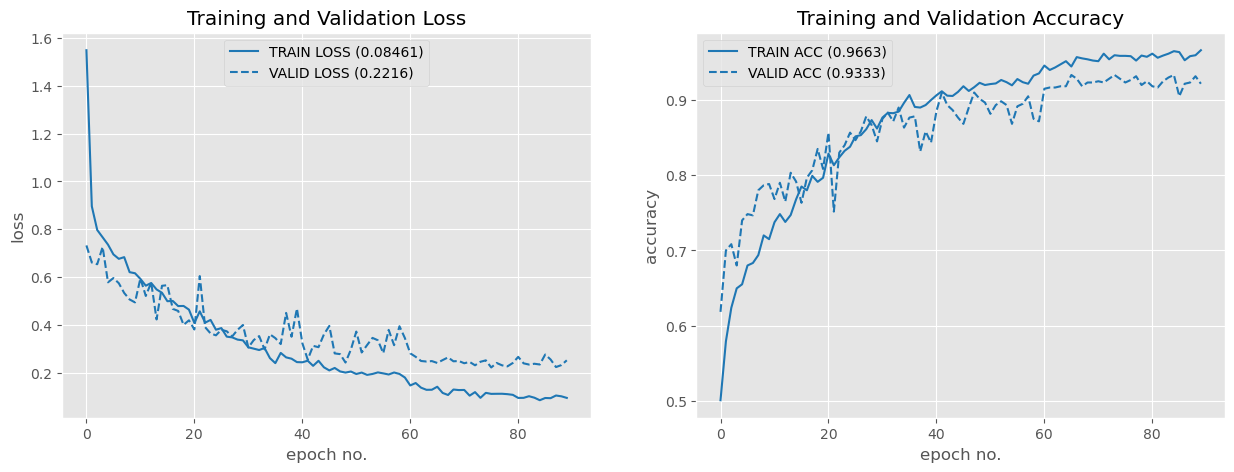

In [32]:
plot_loss_accuracy(train_loss=[metrics.train_loss], 
                   val_loss=[metrics.val_loss], 
                   train_acc=[metrics.train_acc], 
                   val_acc=[metrics.val_acc], 
                   colors=['blue'], 
                   loss_legend_loc='upper center', 
                   acc_legend_loc='upper left',
                   trn_config=train_config)

# <font style="color:blue">Step 5. Sample Prediction</font><a name="step5"></a>

Show some sample predictions.

## <font style="color:blue">5.1. Make Predictions</font>

In [33]:
def prediction(model, device, batch_input):
    
    data = batch_input.to(device)
    
    with torch.no_grad():
        output = model(data)

    # Score to probability using softmax
    prob = F.softmax(output, dim=1)

    # get the max probability
    pred_prob = prob.data.max(dim=1)[0]
    
    # get the index of the max probability
    pred_index = prob.data.max(dim=1)[1]
    
    return pred_index.cpu().numpy(), pred_prob.cpu().numpy()

## <font style="color:blue">5.2. Get Predictions on a Batch</font>

In [35]:
def get_sample_prediction(model, data_root, mean, std):
    batch_size = 15

    if torch.cuda.is_available():
        device = "cuda"
        num_workers = 8
    else:
        device = "cpu"
        num_workers = 2
    
    # It is important to do model.eval() before prediction
    model.eval()
    
    # Send model to cpu/cuda according to your system configuration
    model.to(device)

    # transformed data
    test_dataset_trans = datasets.ImageFolder(root=data_root, transform=image_common_transforms(mean, std))
    
    # original image dataset
    test_dataset = datasets.ImageFolder(root=data_root, transform=image_preprocess_transforms())
    
    data_len = test_dataset.__len__()
    
    interval = int(data_len/batch_size)
    
    imgs = []
    inputs = []
    targets = []
    for i in range(batch_size):
        index = i * interval
        trans_input, target = test_dataset_trans.__getitem__(index)
        img, _ = test_dataset.__getitem__(index)
        
        imgs.append(img)
        inputs.append(trans_input)
        targets.append(target)
        
    inputs = torch.stack(inputs)
        
    cls, prob = prediction(model, device, batch_input=inputs)
    
    plt.style.use('default')
    plt.rcParams["figure.figsize"] = (15, 9)
    fig = plt.figure()
    
    
    for i, target in enumerate(targets):
        plt.subplot(3, 5, i+1)
        img = transforms.functional.to_pil_image(imgs[i])
        plt.imshow(img)
        plt.gca().set_title('P:{0}({1:.2}), T:{2}'.format(test_dataset.classes[cls[i]], 
                                                     prob[i], 
                                                     test_dataset.classes[targets[i]]))
    fig.savefig('sample_prediction.png')
    plt.show()
    
    return
        
    

## <font style="color:blue">5.3. Load Model and Run Inference</font>

In [45]:
model = MyModel()
# print(model)
model = load_model(model, model_dir='models', model_file_name='Model_v81b_BS_006_LR_1.0e-04_p0.4_n_bestloss.pt')
# m = load_model(m)

train_config = TrainingConfiguration()

test_data_path = os.path.join(train_config.data_root, 'validation')
train_data_path = os.path.join(train_config.data_root, 'training')

mean, std = get_mean_std(train_data_path)

mean: tensor([0.4610, 0.4347, 0.3897]), std: tensor([0.2734, 0.2641, 0.2616])


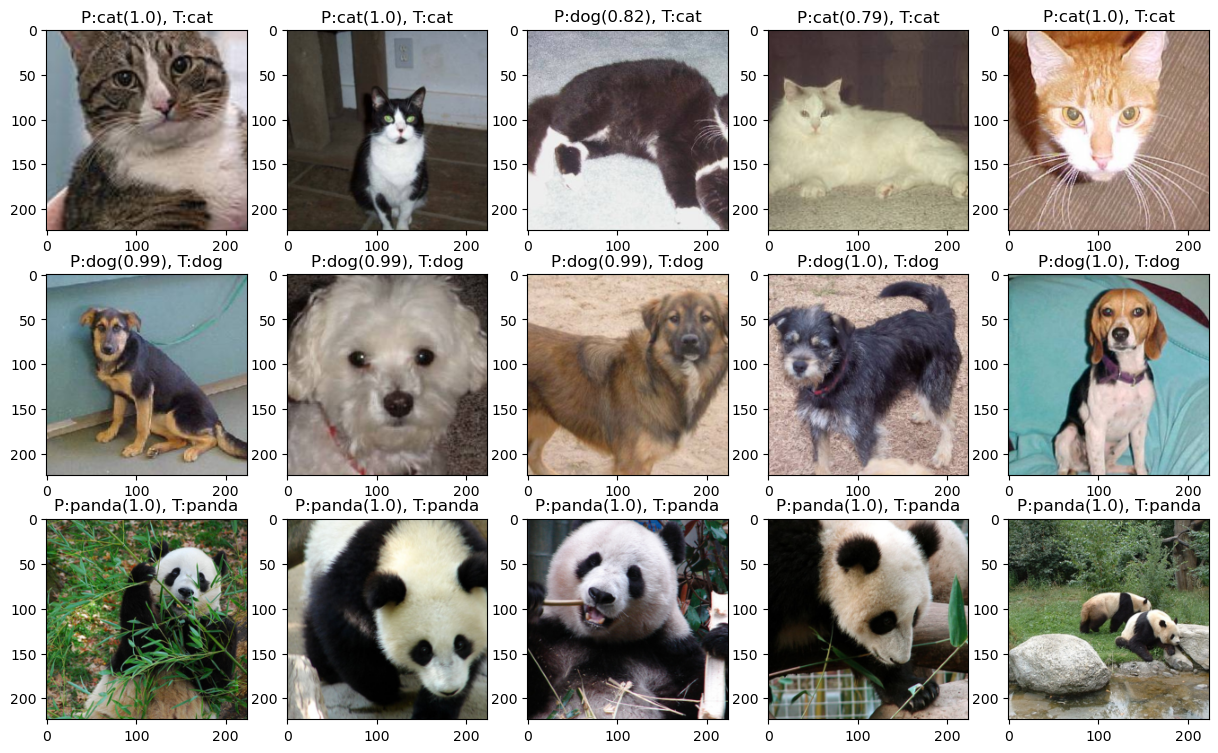

In [46]:
get_sample_prediction(model, test_data_path, mean, std)

# <font style="color:red">Step 6. Display Confusion Matrix [10 Points]</font><a name="step6"></a>

Display the confusion matrix for the above problem(Refer to the earlier lectures on Performance Metrics).


The output should resemble this:

<img src='https://www.learnopencv.com/wp-content/uploads/2020/02/c3_w5_sample_confusion_matrix.png' width=600>


In [ ]:
# YOUR CODE HERE

### <font style="color:red">Confusion Matrix</font><a name="step6"></a>

In [47]:
_, test_loader = get_data(batch_size=30,
                          data_root='./cat-dog-panda',
                          num_workers=2,
                          data_augmentation=True,
                         )

mean: tensor([0.4610, 0.4347, 0.3897]), std: tensor([0.2734, 0.2641, 0.2616])


In [48]:
if torch.cuda.is_available():
    device = "cuda"
    num_workers = 8
else:
    device = "cpu"
    num_workers = 2

# It is important to do model.eval() before prediction
_ = model.eval()
# Send model to cpu/cuda according to your system configuration
_ = model.to(device)

In [49]:
y_true = np.ndarray(0)
y_pred = np.ndarray(0)
y_prob = np.ndarray(0)

for batch_id, (data, target) in enumerate(test_loader,1):
    pred, prob = prediction(model, device, batch_input=data.to(train_config.device))
    print(f" batch_id: {batch_id}")
    y_pred = np.concat((y_pred, pred), axis =0)
    y_prob = np.concat((y_prob, prob), axis =0)
    y_true = np.concat((y_true, target.cpu().numpy()))

 batch_id: 1
 batch_id: 2
 batch_id: 3
 batch_id: 4
 batch_id: 5
 batch_id: 6
 batch_id: 7
 batch_id: 8
 batch_id: 9
 batch_id: 10
 batch_id: 11
 batch_id: 12
 batch_id: 13
 batch_id: 14
 batch_id: 15
 batch_id: 16
 batch_id: 17
 batch_id: 18
 batch_id: 19
 batch_id: 20


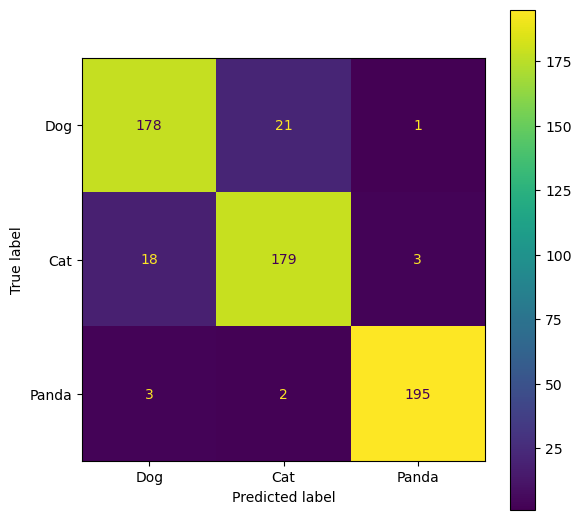

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6.5,6.5))
ConfusionMatrixDisplay.from_predictions(y_true=y_true, y_pred=y_pred, display_labels=['Dog', 'Cat', 'Panda'],ax=ax)

Upon completing the assignment,  <font style="color:red">pload the 2 notebooks and the models folder on the portal for feedback.</font>